# baseline v3

이 베이스라인 코드는 `사전학습 모델 로드`, `배치 학습`, `파인튜닝`, `양자화`, `PEFT` 등이 적용된 버전입니다.

윈도우 데스크탑의 RTX 5060 ti GPU 환경에서 개발되었습니다.

# 환경 준비

개발 환경에 필요한 라이브러리 버전을 고정하고 최신 버전으로 라이브러리를 업데이트합니다.

- 아래 셀 실행
- ipykernel 설치
- 아래 셀 다시 실행 : 무한 로딩 시 restart
- hello 출력시 torch 설치

In [ ]:
# print('hello123')

In [1]:
!pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128


In [2]:
!pip install "pandas==2.2.2" "pillow>=8.0,<12.0" --break-system-packages

In [3]:
!python -c "import pandas as pd; import PIL; print('pandas:', pd.__version__, '/ pillow:', PIL.__version__)"
# 기대 출력: pandas: 2.2.2 / pillow: 11.x.x

pandas: 2.2.2 / pillow: 11.3.0


In [4]:
!pip show pandas | grep Version
!pip show Pillow | grep Version

Version: 2.2.2
Version: 11.3.0


In [5]:
!pip -q install \
  "transformers>=4.43.2,<5.0.0" \
  "accelerate>=0.34.2" \
  "peft>=0.13.2" \
  "bitsandbytes>=0.43.3" \
  "datasets" \
  "pillow>=8.0,<12.0" \
  "pandas==2.2.2" \
  --break-system-packages

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 163.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 57.5 MB/s eta 0:00:00


In [6]:
!pip install matplotlib ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.2 MB/s eta 0:00:00


# 데이터 준비

개발에 필요한 데이터를 준비합니다.

- train.csv, train 폴더
- test.csv, test 폴더
- sample_submission.csv

데이터를 압축 해제하는데 몇 분 정도의 시간이 소요됩니다.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# 압축 해제
!unzip "/content/drive/My Drive/260401_15_2_ai_데이터배포용.zip" -d "/content/"

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/train/train_0074.jpg  
  inflating: /content/train/train_0075.jpg  
  inflating: /content/train/train_0076.jpg  
  inflating: /content/train/train_0077.jpg  
  inflating: /content/train/train_0078.jpg  
  inflating: /content/train/train_0079.jpg  
  inflating: /content/train/train_0080.jpg  
  inflating: /content/train/train_0081.jpg  
  inflating: /content/train/train_0082.jpg  
  inflating: /content/train/train_0083.jpg  
  inflating: /content/train/train_0084.jpg  
  inflating: /content/train/train_0085.jpg  
  inflating: /content/train/train_0086.jpg  
  inflating: /content/train/train_0087.jpg  
  inflating: /content/train/train_0088.jpg  
  inflating: /content/train/train_0089.jpg  
  inflating: /content/train/train_0090.jpg  
  inflating: /content/train/train_0091.jpg  
  inflating: /content/train/train_0092.jpg  
  inflating: /content/train/train_0093.jpg  
  inflating: /content/train/train_0094.jpg  
  inflating: /conte

# 라이브러리, 데이터, 설정

In [9]:
import os, re, math, random, json, gc
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
import torch
from typing import Dict, List, Any
from transformers import (
    AutoModelForVision2Seq,
    AutoProcessor,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from tqdm.notebook import tqdm
import warnings
from datetime import datetime
from peft import PeftModel
import matplotlib.pyplot as plt
from IPython.display import display

%config InlineBackend.figure_format = 'retina'

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [10]:
# 경고 출력 설정
warnings.filterwarnings(action="ignore")

# 이미지 로드 시 픽셀 제한 해제
Image.MAX_IMAGE_PIXELS = None

# 디바이스 GPU 우선 사용 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# 사전 학습 모델 정의
# MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"
MODEL_ID = "Qwen/Qwen3-VL-30B-A3B-Instruct"
IMAGE_SIZE = 512
MAX_NEW_TOKENS = 8
SEED = 42
random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# 학습 하이퍼파라미터 세팅
LEARNING_RATE = 1e-4
EPOCHS = 2
GRAD_ACCUM = 8
COMPUTE_DTYPE = torch.float16
LOAD_IN_4BIT = True

# LoRA 하이퍼파라미터 세팅
LORA_R = 64
LORA_ALPHA = 128
LORA_DROPOUT = 0.05
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

Device: cpu


# 모델, Processor

7.5GB 정도의 모델 다운로드가 진행됩니다. 10~20분 정도가 소요됩니다.

#### 실습 참고 내용

    챕터 5-1 PEFT(파라미터 효율적 튜닝)
    - LoRA 구현 : LoraConfig()

In [11]:
# VRAM 안전 초기화
try:
    del model
except NameError:
    pass

try:
    del base_model
except NameError:
    pass

torch.cuda.empty_cache()
gc.collect()

# 양자화
bnb_config = BitsAndBytesConfig(
    load_in_4bit=LOAD_IN_4BIT,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

# 프로세서
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=IMAGE_SIZE*IMAGE_SIZE,
    max_pixels=IMAGE_SIZE*IMAGE_SIZE,
    trust_remote_code=True,
)
processor.tokenizer.padding_side = "right"
if processor.tokenizer.pad_token is None:
    print("패딩 토큰이 없어서 eos_token으로 대체합니다.")
    processor.tokenizer.pad_token = processor.tokenizer.eos_token
    processor.tokenizer.pad_token_id = processor.tokenizer.eos_token_id

# 사전학습 모델
base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# 양자화 모델로 로드
base_model = prepare_model_for_kbit_training(base_model)
base_model.gradient_checkpointing_enable()

# LoRA 세팅
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    target_modules=TARGET_MODULES,
    task_type="CAUSAL_LM",
)

# PEFT 모델 생성
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00012-of-00013.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00013-of-00013.safetensors:   0%|          | 0.00/2.91G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/13 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

trainable params: 53,477,376 || all params: 31,124,231,408 || trainable%: 0.1718


## 🚨 학습을 하지 않고 추론을 하는 경우 아래 셀을 실행할 것

In [ ]:
# 1. 불러올 LoRA 폴더 경로 설정
LORA_DIR = "qwen3_vl_8b_lora_20260331_175858"

print("양자화 설정 적용 및 모델 로딩 시작...")

# 2. 4비트 양자화 설정
bnb_config = BitsAndBytesConfig(
    load_in_4bit=LOAD_IN_4BIT,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

# 3. 프로세서 로드 (저장해둔 LoRA 폴더의 세팅을 그대로 가져옴)
processor = AutoProcessor.from_pretrained(
    LORA_DIR,
    trust_remote_code=True
)

# 4. 깡통 베이스 모델 로드
base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

print("LoRA 가중치 덧씌우는 중...")

# 5. 베이스 모델 위에 학습된 LoRA 가중치 결합
model = PeftModel.from_pretrained(base_model, LORA_DIR)

양자화 설정 적용 및 모델 로딩 시작...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LoRA 가중치 덧씌우는 중...


# 프롬프트 템플릿

#### 실습 참고 내용

    챕터 5-1 PEFT(파라미터 효율적 튜닝)
    - 프롬프트 템플릿 : convert_to_chatml(), formatting_prompts_func()

In [12]:
# # 모델 지시사항
# SYSTEM_INSTRUCT = (
#     "You are a helpful visual question answering assistant. "
#     "Answer using exactly one letter among a, b, c, or d. No explanation."
# )

# # 프롬프트
# def build_mc_prompt(question, a, b, c, d):
#     return (
#         f"{question}\n"
#         f"(a) {a}\n(b) {b}\n(c) {c}\n(d) {d}\n\n"
#         "정답을 반드시 a, b, c, d 중 하나의 소문자 한 글자로만 출력하세요."
#     )

SYSTEM_INSTRUCT = (
    "You are an expert model for multiple-choice visual question answering.\n"
    "You will be given one image and one question with four options.\n"
    "Decide which option is best supported by the image and the question.\n\n"
    "Decision policy:\n"
    "- Use the image as the main source of truth.\n"
    "- Ground your choice in directly visible evidence such as objects, people, scene type, layout, actions, and any readable text in the image.\n"
    "- Compare all four options before answering.\n"
    "- Eliminate options that are contradicted by the image or are less supported by the visible evidence.\n"
    "- Prefer the option with the strongest direct visual support, not the one that is merely plausible from general world knowledge.\n"
    "- If the image is ambiguous, partially occluded, or incomplete, choose the single option best supported by the visible evidence and the question.\n"
    "- Do not abstain and do not output multiple answers.\n"
    "- Keep reasoning internal.\n\n"
    "Output rules:\n"
    "- Output ONLY a single lowercase letter: a, b, c, or d.\n"
    "- Do NOT output explanations, punctuation, spaces, or any other text.\n"
    "- Correct outputs: a / b / c / d\n"
    "- Incorrect outputs: (a) / A / answer: a / 'b' / b."
)

def build_mc_prompt(question, a, b, c, d):
    return (
        f"Question: {question}\n\n"
        f"Options:\n"
        f"a: {a}\n"
        f"b: {b}\n"
        f"c: {c}\n"
        f"d: {d}\n\n"
        "Choose the single option best supported by the image and the question.\n"
        "Use direct visual evidence and compare all four options before answering.\n"
        "Answer (single lowercase letter only):"
    )

# Custom Dataset, Collator

#### 실습 참고 내용

    챕터 1-2 MLP 구현
    - TensorDataset()

    챕터 5-2 데이터 생성 및 파인튜닝 (향후 학습 분량)
    - IntentDataset()

In [13]:
# 커스텀 데이터셋
class VQAMCDataset(Dataset):
    def __init__(self, df, processor, train=True):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.train = train

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")

        q = str(row["question"])
        a, b, c, d = str(row["a"]), str(row["b"]), str(row["c"]), str(row["d"])
        user_text = build_mc_prompt(q, a, b, c, d)

        messages = [
            {"role":"system","content":[{"type":"text","text":SYSTEM_INSTRUCT}]},
            {"role":"user","content":[
                {"type":"image","image":img},
                {"type":"text","text":user_text}
            ]}
        ]
        if self.train:
            gold = str(row["answer"]).strip().lower()
            messages.append({"role":"assistant","content":[{"type":"text","text":gold}]})

        return {"messages": messages, "image": img}

# 데이터 콜레이터
@dataclass
class DataCollator:
    processor: Any
    train: bool = True

    def __call__(self, batch):
        texts, images = [], []
        prompt_lengths = [] # 각 문제의 '질문 길이'를 저장할 리스트

        for sample in batch:
            messages = sample["messages"]
            img = sample["image"]

            # 1. 전체 텍스트 (질문 + 정답 "a")
            text = self.processor.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=False
            )
            texts.append(text)
            images.append(img)

            if self.train:
                # 2. 핵심 로직: 정답을 제외한 '프롬프트(질문)' 텍스트만 따로 만들기
                # messages[:-1]은 마지막 assistant의 정답("a")을 제외한 system + user 메시지
                prompt_text = self.processor.apply_chat_template(
                    messages[:-1],
                    tokenize=False,
                    add_generation_prompt=True # 모델이 대답할 차례(<|im_start|>assistant\n)까지만 딱 생성
                )

                # 프롬프트만 토크나이징해서 그 길이(토큰 개수)를 정확히 측정해
                prompt_enc = self.processor(
                    text=[prompt_text],
                    images=[img], # 이미지 토큰 개수까지 완벽하게 계산하기 위해 img 필수
                    return_tensors="pt"
                )
                prompt_lengths.append(prompt_enc["input_ids"].shape[1])

        # 3. 전체 텍스트 토크나이징 (이게 모델에 들어갈 진짜 입력)
        enc = self.processor(
            text=texts,
            images=images,
            padding=True,
            return_tensors="pt"
        )

        if self.train:
            labels = enc["input_ids"].clone()

            # 4. Padding 마스킹: 배치 처리하느라 남는 공간에 채워진 패딩 토큰은 무조건 채점 제외(-100)
            if self.processor.tokenizer.pad_token_id is not None:
                labels[labels == self.processor.tokenizer.pad_token_id] = -100

            # 5. 질문 마스킹: 측정한 프롬프트 길이만큼 앞에서부터 전부 -100으로 덮어버림
            for i, p_len in enumerate(prompt_lengths):
                labels[i, :p_len] = -100

            enc["labels"] = labels

        return enc

# DataLoader

#### 실습 참고 내용

    챕터 3-1 Transfer Learning 기반의 CNN 모델 학습
    - 데이터로더 정의 : DataLoader()

In [17]:
# 데이터셋 로드
train_df = pd.read_csv("/content/train.csv")
test_df  = pd.read_csv("/content/test.csv")

# 학습데이터 200개만 추출
train_df = train_df.sample(n=200, random_state=SEED).reset_index(drop=True)

# 검증용 데이터 분리
split = int(len(train_df)*0.9)
train_subset, valid_subset = train_df.iloc[:split], train_df.iloc[split:]

# VQAMCDataset 형태로 변환
train_ds = VQAMCDataset(train_subset, processor, train=True)
valid_ds = VQAMCDataset(valid_subset, processor, train=True)

# 데이터로더
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=DataCollator(processor, True), num_workers=0)
valid_loader = DataLoader(valid_ds, batch_size=1, shuffle=False, collate_fn=DataCollator(processor, True), num_workers=0)

# fine-tuning

- 200개만 학습 : 10~20분 소요

#### 실습 참고 내용

    챕터 1-2 MLP 구현
    - 모델 정의 : SimpleMLP(), SequentialMLP()

    챕터 3-1 Transfer Learning 기반의 CNN 모델 학습
    - 학습 루프 : 문제 6: 모델 학습을 위한 반복문
    - 추론 : with torch.no_grad(), model.eval()

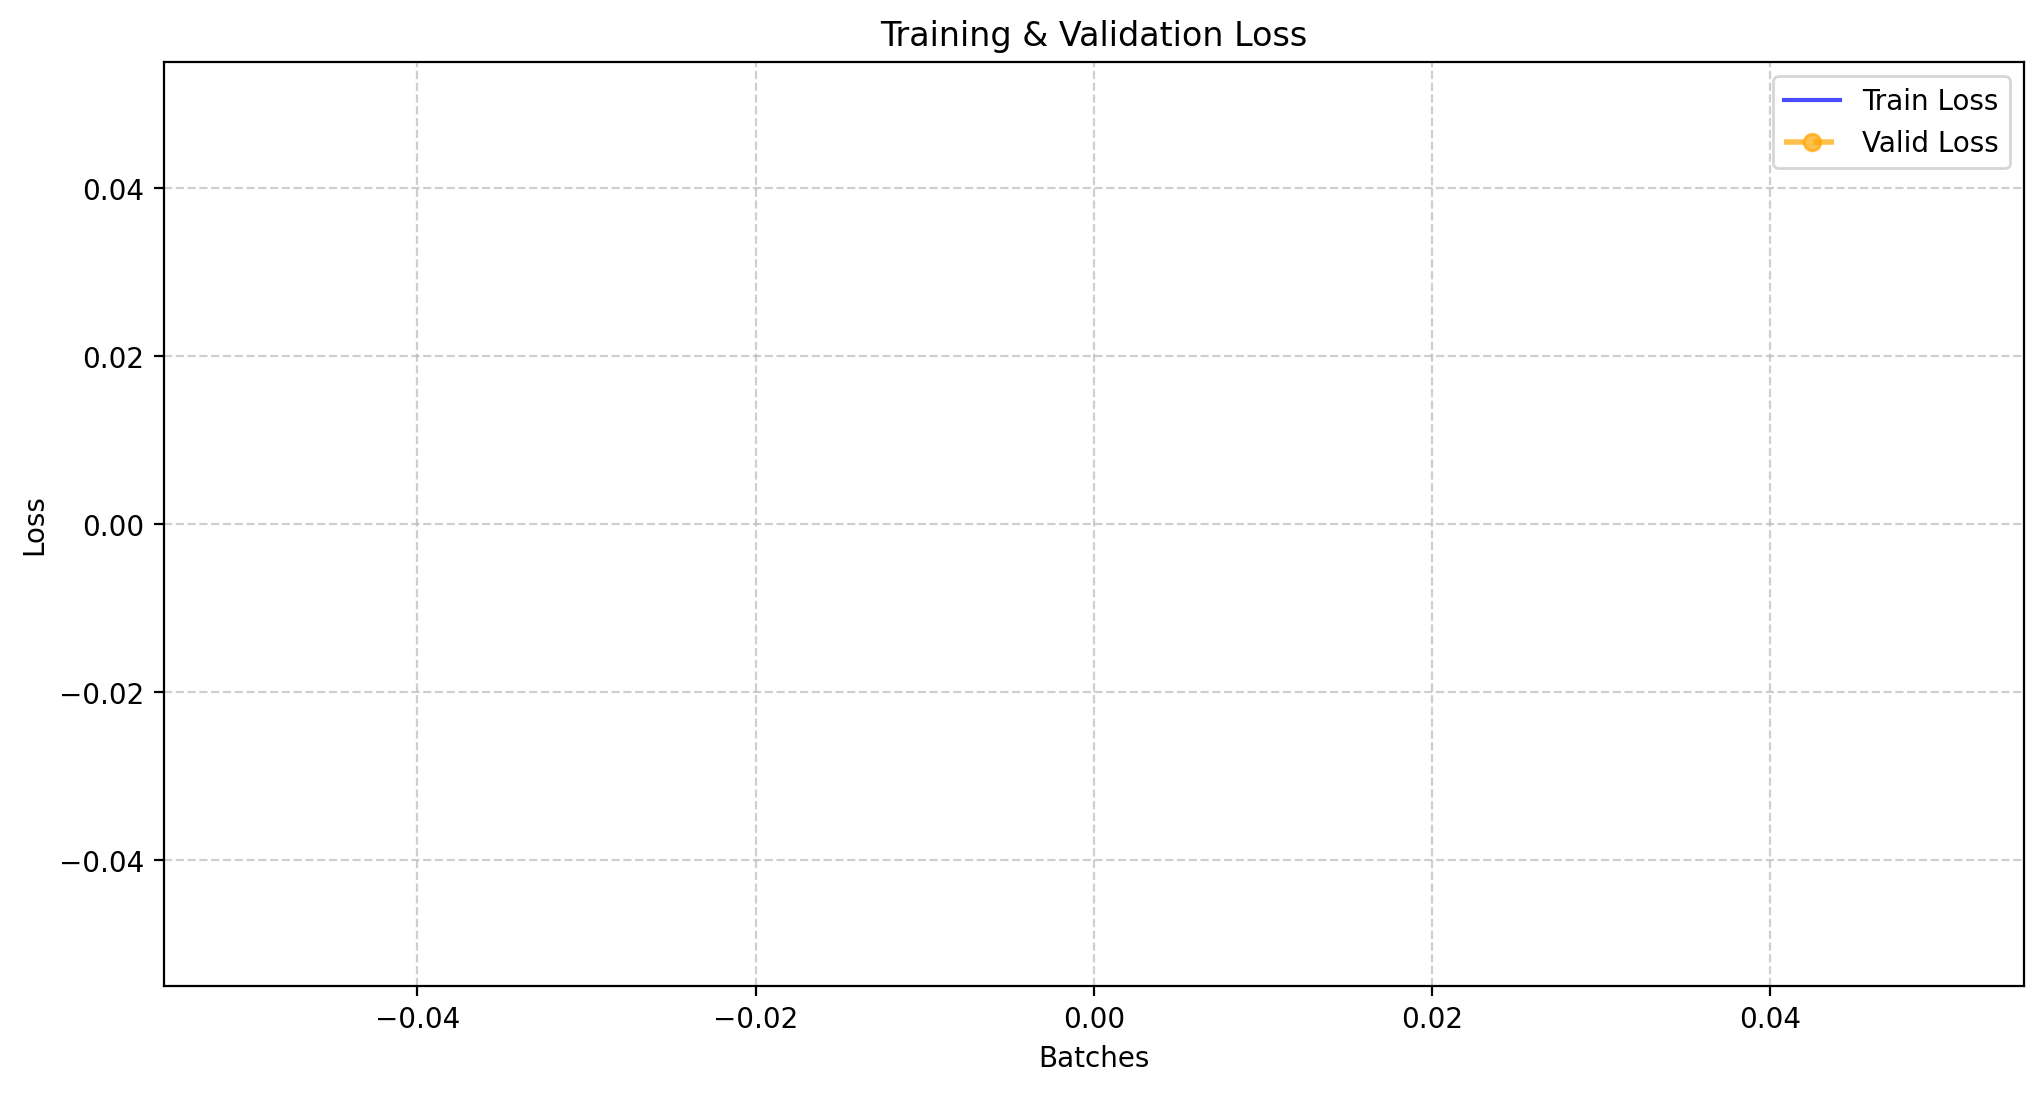

Batch 0 [valid]:   0%|          | 0/20 [00:00<?, ?batch/s]

RuntimeError: Current CUDA Device does not support bfloat16. Please switch dtype to float16.

In [18]:
def run_validation(current_step):
    model.eval()
    val_loss = 0.0
    val_steps = 0

    val_pbar = tqdm(valid_loader, desc=f"Batch {current_step} [valid]", unit="batch", leave=False)
    with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
        for vb in val_pbar:
            vb = {k:v.to(device) for k,v in vb.items()}
            val_loss += model(**vb).loss.item()
            val_steps += 1

    avg_val_loss = val_loss / val_steps

    val_step_history.append(current_step)
    val_loss_history.append(avg_val_loss)
    val_line.set_data(val_step_history, val_loss_history)
    ax.relim()
    ax.autoscale_view()
    graph_display.update(fig)

    model.train() # 다시 학습 모드로 복귀
    return avg_val_loss


# 옵티마이저, 학습 스케줄러
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
num_training_steps = EPOCHS * math.ceil(len(train_loader)/GRAD_ACCUM)
scheduler = get_linear_schedule_with_warmup(optimizer, int(num_training_steps*0.03), num_training_steps)

# 그래프 초기 설정
PLOT_INTERVAL = 10
VAL_INTERVAL = 10

fig, ax = plt.subplots(figsize=(12, 6))
line, = ax.plot([], [], label='Train Loss', color='blue', alpha=0.7)
val_line, = ax.plot([], [], label='Valid Loss', color='orange', marker='o', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Batches')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc="upper right")
plt.close(fig)

graph_display = display(fig, display_id=True)
loss_history = []
step_history = []
val_loss_history = []
val_step_history = []

# 기본 모델(학습 전)의 초기 Validation Loss를 측정
initial_loss = run_validation(0)
print(f"  [Batch    0] Initial Valid Loss: {initial_loss:.4f}")

batch_step = 0
plot_loss_accum = 0.0  # n번의 배치 로스를 모아둘 바구니

# 학습 루프
for epoch in range(EPOCHS):
    running = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [train]", unit="batch")
    for step, batch in enumerate(progress_bar, start=1):
        batch_step += 1

        batch = {k:v.to(device) for k,v in batch.items()}
        with torch.cuda.amp.autocast(dtype=torch.float16):
            outputs = model(**batch)
            loss = outputs.loss / GRAD_ACCUM

        loss.backward()
        running += outputs.loss.item()

        # ---------------------------------------------------------
        # 📈 그래프 데이터 추가 및 갱신 (Train)
        # ---------------------------------------------------------
        plot_loss_accum += outputs.loss.item()

        if batch_step % PLOT_INTERVAL == 0:
            avg_plot_loss = plot_loss_accum / PLOT_INTERVAL

            loss_history.append(avg_plot_loss)
            step_history.append(batch_step)

            line.set_data(step_history, loss_history)
            ax.relim()
            ax.autoscale_view()
            graph_display.update(fig)

            plot_loss_accum = 0.0

        # ---------------------------------------------------------
        # 가중치 업데이트
        # ---------------------------------------------------------
        if step % GRAD_ACCUM == 0 or step == len(train_loader):
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

            actual_accum = GRAD_ACCUM if step % GRAD_ACCUM == 0 else step % GRAD_ACCUM
            avg_loss = running / actual_accum
            progress_bar.set_postfix({"loss": f"{avg_loss:.3f}"})
            running = 0.0

        # ---------------------------------------------------------
        # 검증 루프
        # ---------------------------------------------------------
        # if batch_step % VAL_INTERVAL == 0:
        #     avg_val_loss = run_validation(batch_step)
        #     progress_bar.write(f"  [Batch {batch_step:>4}] Valid Loss: {avg_val_loss:.4f}")

    # Epoch별 Validation Loss 계산
    epoch_val_loss = run_validation(batch_step)
    print(f"[Epoch {epoch+1}] Valid Loss: {epoch_val_loss:.4f}")

# 모델 저장
time_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
SAVE_DIR = f"qwen3_vl_8b_lora_{time_stamp}"
model.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)
print("Saved:", SAVE_DIR)

# 파인튜닝 세팅값(하이퍼파라미터) 저장
custom_config = {
    "MODEL_ID": MODEL_ID,
    "SEED": SEED,
    "IMAGE_SIZE": IMAGE_SIZE,
    "MAX_NEW_TOKENS": MAX_NEW_TOKENS,
    "LEARNING_RATE": LEARNING_RATE,
    "EPOCHS": EPOCHS,
    "GRAD_ACCUM": GRAD_ACCUM,
    "COMPUTE_DTYPE": str(COMPUTE_DTYPE),
    "LOAD_IN_4BIT": LOAD_IN_4BIT,
    "LORA_R": LORA_R,
    "LORA_ALPHA": LORA_ALPHA,
    "LORA_DROPOUT": LORA_DROPOUT,
    "TARGET_MODULES": TARGET_MODULES
}
config_path = os.path.join(SAVE_DIR, "train_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(custom_config, f, indent=4, ensure_ascii=False)
print("Saved:", config_path)

# inference

30분~1시간 소요

#### 실습 참고 내용

    챕터4-1 RAG 기반 Customer Service AI 에이전트 개발
    - 데이터 파서 : langchain_core.output_parsers(), StrOutputParser()

    챕터 3-1 Transfer Learning 기반의 CNN 모델 학습
    - 학습 루프 : 문제 6: 모델 학습을 위한 반복문
    - 추론 : with torch.no_grad(), model.eval()

In [ ]:
# 데이터 파서 : 모델의 응답에서 선지를 추출
def extract_choice(text: str) -> str:
    text = text.strip().lower()

    lines = [l.strip() for l in text.splitlines() if l.strip()]
    if not lines:
        return "a"
    last = lines[-1]
    if last in ["a", "b", "c", "d"]:
        return last

    tokens = last.split()
    for tok in tokens:
        if tok in ["a", "b", "c", "d"]:
            return tok
    return "a"

# 추론을 위해 모든 레이어 활성화
model.eval()
preds = []

# 추론 루프
for i in tqdm(range(len(test_df)), desc="Inference", unit="sample"):
    row = test_df.iloc[i]
    img = Image.open(row["path"]).convert("RGB")
    user_text = build_mc_prompt(row["question"], row["a"], row["b"], row["c"], row["d"])

    messages = [
        {"role":"system","content":[{"type":"text","text":SYSTEM_INSTRUCT}]},
        {"role":"user","content":[
            {"type":"image","image":img},
            {"type":"text","text":user_text}
        ]}
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors="pt").to(device)

    with torch.no_grad():
        out_ids = model.generate(**inputs, max_new_tokens=2, do_sample=False,
                                 eos_token_id=processor.tokenizer.eos_token_id)

    generated_ids = [
        out_id[len(in_id):] for in_id, out_id in zip(inputs.input_ids, out_ids)
    ]
    output_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    preds.append(extract_choice(output_text))

# 제출 파일 생성
submission = pd.DataFrame({"id": test_df["id"], "answer": preds})
submission.to_csv(os.path.join(SAVE_DIR if SAVE_DIR else LORA_DIR, "submission.csv"), index=False)
print("Saved submission.csv")

Inference:   0%|          | 0/5074 [00:00<?, ?sample/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Saved submission.csv
